# Señales Sinusoidales Parametrizadas

## Análisis y Procesamiento de señales - TS0
García Corona, Iara Paula
<p style="margin-left: 30px;">
En este primer código se muestra la definición de la función seno para una señal senoidal muestreada.
</p>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# funciones
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    xx=dc+vmax*np.sin(2*np.pi*ff*nn/fs+2*np.pi*ph)
    tt=nn/fs
    return(tt,xx)

Donde:

* <span style="color: purple;">**vmax:**</span> Amplitud máxima que puede tomar la señal
* <span style="color: purple;">**dc:**</span> Valor alrededor del cual oscila la señal
* <span style="color: purple;">**ff:**</span> Frecuencia de la señal (en Hz)
* <span style="color: purple;">**ph:**</span> Fase inicial
* <span style="color: purple;">**nn:**</span> Índices de muestreo
* <span style="color: purple;">**fs:**</span> Frecuencia de muestreo
  
>Con estos valores el usuario puede parametrizar las "cc.ii." de la señal que quiere generar.

La función retorna dos vectores: **tt** y **xx**.<br>
<p style="margin-left: 30px;">
<span style="color: blue;"><b>tt</b></span> representa el tiempo en segundos<br>
<span style="color: blue;"><b>xx</b></span> representa el vector de amplitudes para cada punto del tiempo<br>
</p>

Se declaran los parámetros que se desean utilizar en la función:

In [2]:
# Parámetros
fs = 1000 # [Hz]
N = 1000 # muestras
vmax=1 # [V] potencial máximo (aka apmlitud máxima)
dc=0 # [V] Valor medio (alrededor del que oscila)
ph = 0 # fase (phase)
nn = np.arange(0,N) # vector con índices de muestreo
ff=1 # frecuencia de la señal
tt, xx= mi_funcion_sen(vmax, dc, ff, ph, nn, fs)

Se considera importante señalar dos puntos:<br>
- Se define _**nn**_ como vector para los distintos índices de muestreo. Para definir su tamaño se utiliza la variable N, la cual indica la cantidad de muestras que se consideran para el análisis.<br>
- Como muestra del caso más simple se elije como primer valor de frecuencia 1Hz (ff=1Hz), ya que la frecuencia de muestreo y la cantidad de muestras acotan la fracción de señal que se muestra. Tomar la frecuencia en 1Hz implica tener un periodo $T= \frac{1}{f}=\frac{N}{f_s}=1s$, permitiendo visualizar exactamente un ciclo de la señal.

Finalmente se llama a la función.

Como primer acercamiento se puede graficar la señal sinusoidal básica para chequear el correcto funcionamiento de la función creada.<br><span style="color: gray;">Se agrega una grilla que permite visualizar de manera más clara el voltaje máximo y el tiempo del periodo.</span>

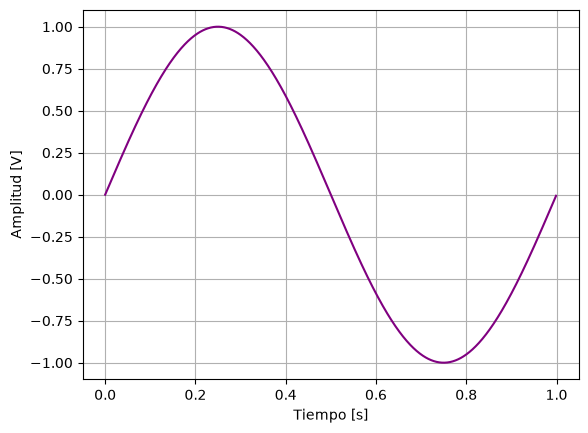

In [3]:
# Gráfico

plt.figure()
plt.plot(tt,xx, color="purple") #imprime los datos 
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid(True) #Para mostrar una grilla de fondo
plt.show()

Para poder realizar un mejor análisis de la señal se busca generar distintos resultados considerando diversas frecuencias.

In [23]:
ff_1=500 # RUIDO
ff_2=999 # invertida
ff_3=1001 # por periodicidad vuelve al 1
ff_4=2001 # por periodicidad vuelve al 1
ff_5=1000 # RUIDO

In [24]:
# Script
tt, xx= mi_funcion_sen(vmax, dc, ff, ph, nn, fs)
tt, xx_1= mi_funcion_sen(vmax, dc, ff_1, ph, nn, fs)
tt, xx_2= mi_funcion_sen(vmax, dc, ff_2, ph, nn, fs)
tt, xx_3= mi_funcion_sen(vmax, dc, ff_3, ph, nn, fs)
tt, xx_4= mi_funcion_sen(vmax, dc, ff_4, ph, nn, fs)
tt, xx_5= mi_funcion_sen(vmax, dc, ff_5, ph, nn, fs)

Para mostrar en un mismo gráfico podría usarse el siguiente método

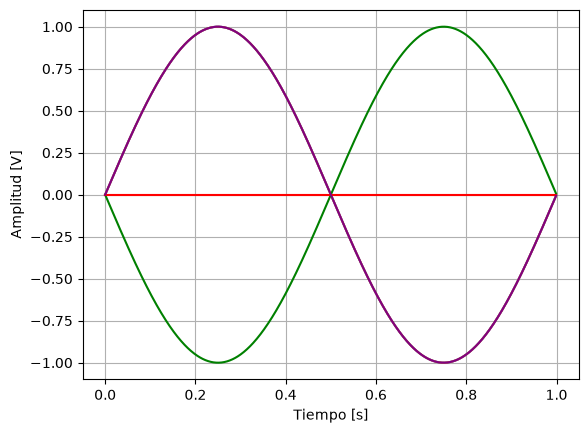

In [25]:
# Gráfico

plt.figure()
plt.plot(tt,xx_5, color="pink") #imprime los datos
plt.plot(tt,xx_4, color="blue") #imprime los datos
plt.plot(tt,xx_3, color="orange") #imprime los datos
plt.plot(tt,xx_2, color="green") #imprime los datos
plt.plot(tt,xx_1, color="red") #imprime los datos
plt.plot(tt,xx, color="purple") #imprime los datos 
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid(True) #Para mostrar una grilla de fondo
plt.show()

Pero la visualización de las distintas respuestas de la función a las frecuencias no logra apreciarse, por lo que se recurre al siguiente ploteo que facilita el análisis de cada resultado.

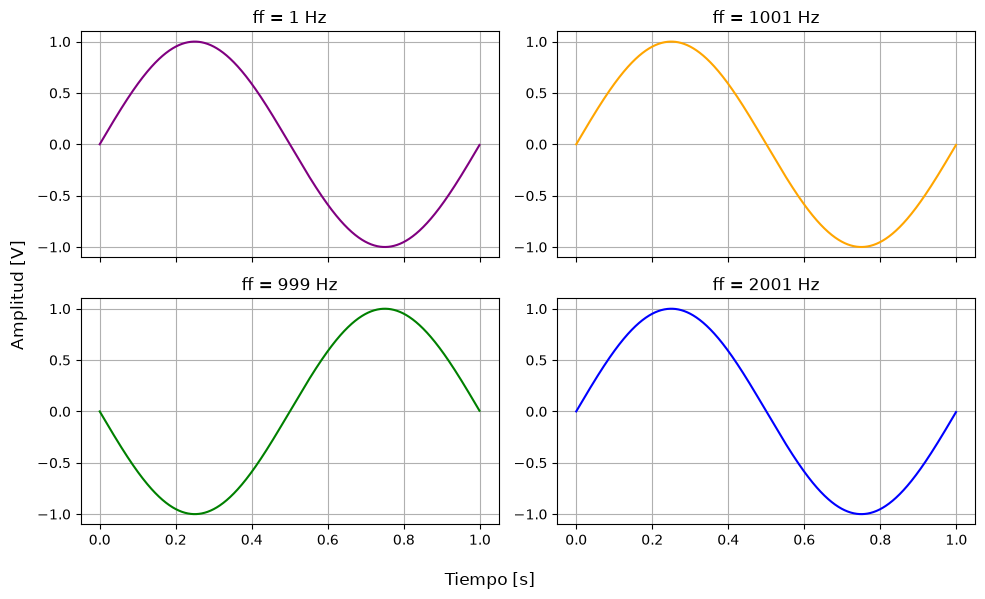

In [26]:
# Armamos una grilla de subplots (3 filas x 2 columnas, por ejemplo)
fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharex=True)

# Organizamos las señales y sus títulos en una lista para recorrerlas
señales = [
    (xx,   "ff = 1 Hz", "purple"),
    (xx_3, "ff = 1001 Hz", "orange"),
    (xx_2, "ff = 999 Hz", "green"),
    (xx_4, "ff = 2001 Hz", "blue"),
]

# axs es una matriz de 3x2, la "aplanamos" para recorrerla con un solo índice
axs = axs.flatten()

for ax, (señal, titulo, color) in zip(axs, señales):
    ax.plot(tt, señal, color=color)
    ax.set_title(titulo)
    ax.grid(True)

fig.supxlabel("Tiempo [s]")
fig.supylabel("Amplitud [V]")
plt.tight_layout()
plt.show()

Para esta instancia es necesario considerar el Teorema de Nyquist-Shannon. Este define que:
$$f_N = \frac{f_s}{2}$$
donde la frecuencia de Nyquist demarca el valor límite para que no se genere un solapamiento entre las repeticiones del espectro.
Por lo tanto, para que esto no ocurra se busca que la frecuencia de la señal sea estrictamente menor que la frecuencia de Nyquist.<br>
En este ejercicio: $f_N = \frac{1000Hz}{2}=500Hz$<br>
Con $ff=1Hz$, se puede ver una sinusoidal de un único ciclo de forma clara ya que $ff<<f_N$
Por periodicidad de la función, en los casos de $ff=1001Hz$ y $ff=2001Hz$ se replica la función de 1Hz lo cual es simple de demostrar trabajando con la expresión planteada inicialmente para el seno:
$$sen(2\pi\frac{1001}{1000}n)=sen(2\pi n+2\pi\frac{1}{1000}n)$$
Como n es siempre un número entero, el primer término del argumento no aporta variaciones, devolviendo como resultado la misma respuesta que se espera en el caso de $ff=1Hz$ y cualquier frecuencia que difiera en 1Hz siendo múltiplo de fs.<br>
En el caso de $ff=999Hz$ el análisis matemático es similar:
$$sen(2\pi\frac{999}{1000}n)=sen(2\pi n-2\pi\frac{1}{1000}n)=-sen(2\pi\frac{1}{1000}n)$$
Resultado que se ve con la gráfica de un seno invertido a la señal de referencia.

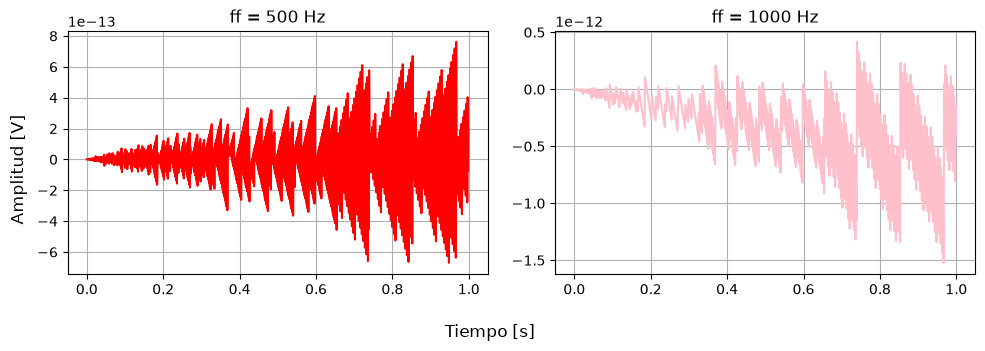

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3.5), sharex=True)
señales2 = [
    (xx_1, "ff = 500 Hz", "red"),
    (xx_5, "ff = 1000 Hz", "pink"),
]
axs = axs.flatten()
for ax, (señal, titulo, color) in zip(axs, señales2):
    ax.plot(tt, señal, color=color)
    ax.set_title(titulo)
    ax.grid(True)
fig.supxlabel("Tiempo [s]")
fig.supylabel("Amplitud [V]")
plt.tight_layout()
plt.show()

Ambos casos caen en los ceros de la función:
$$ sen(2\pi \frac{500}{1000}n)=sen(\pi n)=0\quad\forall\, n$$ y $$ sen(2\pi \frac{1000}{1000}n)=sen(2\pi n)=0\quad\forall\,n$$
Son las frecuencias límite que rompen con la desigualdad estricta que plantea el teorema, lo cual demuestra por qué esta es relevante. Independientemente de la amplitud original de la función, el resultado será siempre cero, impidiendo reconstruir la respuesta en este espectro.<br> Lo que se ve en los gráficos se debe a una limitación del sistema ya que computacionalmente no se utilizan todas las cifras de pi. Este error se acumula al aumentar las muestras y son estos valores los que aparecen en la gráfica como un ruido residual. Esta idea se ve reforzada por el orden de magnitud con el que están descriptas las ondas.